In [2]:
import torch
import numpy as np
from matplotlib import pyplot as plt
import cv2

from tqdm import tqdm

import os
from Dataset.data import DataPath
from Dataset.DataSetLoaders.ChessDataset import ChessDataset

In [3]:
from BoardDetection.BoardDetector_YOLO_Saddle import Bounded_Saddle_Yolo
from BoardDetection.BoardDetector_YOLO_Lattice import main_yolo
from BoardDetection.BoardDetector_Saddle import BoardDetection_saddle
from PIL import Image
from torchvision import transforms

BE = Bounded_Saddle_Yolo.BoardExtractor()

# replace with method being tested
def extractCorners_yolo_saddle(img: torch.Tensor) -> torch.Tensor: # [4,2]
    BE.set_img(img)
    quad, conf = BE.extract_board()
    quad = torch.tensor(quad, dtype=torch.float32)

    return quad

def extractCorners_yolo_lines(img: torch.Tensor) -> torch.Tensor: # [4,2]
    M, corners, mask_fit, error = main_yolo.detect_board_img(img)
    return corners

def extractCorners_saddle(img: torch.Tensor) -> torch.Tensor: # [4,2]
    corners = BoardDetection_saddle.detect(img)
    return torch.tensor(corners, dtype=torch.float32)

In [4]:
def get_mask(corners: torch.Tensor, size: tuple[int, int]) -> torch.Tensor:
    mask = np.zeros(size)
    mask = cv2.fillPoly(mask, [corners.numpy().astype(np.int32)], 1)
    return torch.tensor(mask, dtype=torch.float32)

In [5]:
def get_acc(corners_prime: torch.Tensor, corners: torch.Tensor, img_shape: tuple[int, int]) -> float:
    # IOU
    mask_prime = get_mask(corners_prime, img_shape)
    mask = get_mask(corners, img_shape)
    intersection = torch.sum(mask * mask_prime)
    union = torch.sum((mask + mask_prime) > 0)
    return (intersection / union).item()

In [6]:
def plot_acc(img, y_prime, y):
    mask = get_mask(y, img.shape[:2])
    mask_prime = get_mask(y_prime, img.shape[:2])
    plt.imshow(img, cmap='gray');
    plt.imshow(mask, alpha=mask*.5, cmap='Blues');
    plt.imshow(mask_prime, alpha=mask_prime*.5, cmap='Reds');

    acc = get_acc(y_prime, y, img.shape)
    return acc

In [7]:
dataset = ChessDataset(target_transforms=lambda x: x["corners"], config={
    "img_size": (640,640),
})
len(dataset)

389

tensor([[138., 105.],
        [479., 104.],
        [636., 531.],
        [ 16., 544.]])


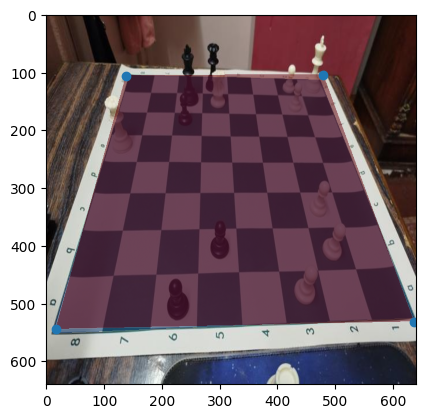

In [ ]:
# Github Saddle Points

img, y = dataset[340]

y_prime = extractCorners_yolo_saddle(img)
print(y_prime)

# --------------------------------------

plot_acc(img.permute(1,2,0), y_prime, y)
plt.scatter(y_prime[:,0], y_prime[:,1]);

In [8]:
accs = []

for i in tqdm(range(len(dataset))):
    img,y = dataset[i]
    y_prime = extractCorners_yolo_saddle(img)

    acc = get_acc(y_prime, y, img.shape)
    accs.append(acc)

# Time: 1m 20s
print(sum(accs)/len(accs), min(accs), max(accs))

100%|██████████| 389/389 [00:33<00:00, 11.75it/s]

0.9793122576257564 0.938811182975769 1.0


In [9]:
dataset = ChessDataset(target_transforms=lambda x: x["corners"], config={
    "img_size": (500,500),
    "gray": True,
    "is_int": True,
})
len(dataset)

389

0.9789862632751465

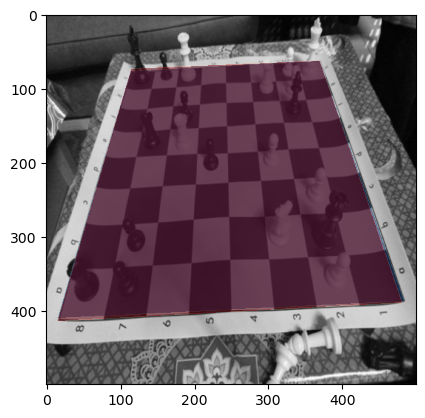

In [9]:
# Github Saddle Points

img, y = dataset[0]

y_prime = extractCorners_saddle(img)

plot_acc(img.permute(1,2,0), y_prime, y)

In [ ]:
accs = []

for i in tqdm(range(len(dataset))):
# for i in tqdm(range(10)):
    if i == 32:
        continue
    try:
        img,y = dataset[i]
        y_prime = extractCorners_saddle(img)

        acc = get_acc(y_prime, y, (3,*img.shape))
        accs.append(acc)
    except Exception as e:
        accs.append(0)
        print(e)

# Time: 9m 26s
print(sum(accs)/len(accs), min(accs), max(accs))

 28%|██▊       | 101/366 [03:14<07:35,  1.72s/it]/mnt/D/University/Thesis/src/BoardDetection/BoardDetector_Saddle/BoardDetection_saddle.py:279: RuntimeWarning: divide by zero encountered in divide
  grid[:, :2] /= grid[:, 2]
100%|██████████| 366/366 [09:26<00:00,  1.55s/it]

0.9935965366559486 0.5081967115402222 1.0
